# Deteksi Phishing URL — XGBoost + PhiUSIIL (Versi Anti-Leakage & Ditingkatkan)

**Masalah versi lama:** akurasi ~99.9% itu **palsu** karena *data leakage*:
- Fitur konten/DOM (`NoOfCSS`, `HasCopyrightInfo`, ...) **bocor** — banyak halaman phishing di PhiUSIIL sudah mati saat di-crawl (kosong), jadi model belajar aturan palsu "halaman kosong = phishing".
- Fitur `URLSimilarityIndex` / `TLDLegitimateProb` adalah **target-encoding** (dihitung dari label) → leakage langsung.
- Saat backend men-scrape `google.com`, fitur kontennya menjadi 0 → model salah memvonis **phishing 1.000** (*train-serving skew*).

**Pipeline versi ini (anti-leakage + ditingkatkan):**
1. **~41 fitur leksikal URL** yang deterministik & bisa direproduksi dari string URL (panjang, rasio digit/huruf, entropy, token mencurigakan, IP/port/punycode, obfuscation, dst).
2. Ekstraksi memakai modul **`url_features.py` yang sama persis** dengan backend → *skew* = 0.
3. **Split per-domain** (`GroupShuffleSplit`) → domain tak bocor train↔test.
4. **RFECV** (sel 4b, fit di training saja) → pilih subset fitur terbaik.
5. **Tuning hyperparameter domain-aware** (sel 4c, `GroupKFold` + `RandomizedSearchCV`, skor F1-phishing) → tuning tidak bocor antar-domain.
6. **Early stopping** + **optimasi threshold** keputusan (sel 5b, dioptimasi di validasi, bukan test).
7. Evaluasi jujur (fokus metrik **phishing**), **permutation test**, **SHAP** (sel 7b), dan **sanity check URL nyata** (google.com dll).

> Akurasi yang lebih realistis (mis. ~88–95%) itu **sehat** — mencerminkan performa nyata pada domain baru, bukan hafalan artefak dataset. Untuk deteksi phishing, **Recall phishing** & **F1 phishing** lebih penting daripada akurasi mentah.

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import (
    GroupShuffleSplit, GroupKFold, RandomizedSearchCV, permutation_test_score,
)
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve, auc, make_scorer,
)

# Modul ekstraksi fitur BERSAMA -> dipakai juga oleh backend (app.py).
# Inilah kunci anti train-serving skew: fitur dihitung dengan fungsi yang sama
# baik saat training (notebook ini) maupun saat inference (Flask).
from url_features import extract_url_features, extract_registered_domain, FEATURE_ORDER

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Kelas positif untuk metrik = PHISHING (label 0) -> itu yang ingin kita deteksi.
f1_phish = make_scorer(f1_score, pos_label=0)

print("Setup OK. Jumlah fitur leksikal:", len(FEATURE_ORDER))
print(FEATURE_ORDER)

Setup OK. Jumlah fitur leksikal: 41
['URLLength', 'DomainLength', 'TLDLength', 'PathLength', 'QueryLength', 'NoOfSubDomain', 'SubdomainLength', 'LongestTokenLength', 'NoOfTokens', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDigitsInURL', 'DigitRatioInURL', 'NoOfDigitsInDomain', 'DomainDigitRatio', 'VowelRatioInURL', 'URLEntropy', 'DomainEntropy', 'CharContinuationRate', 'NoOfDotsInURL', 'NoOfHyphensInURL', 'NoOfHyphensInDomain', 'NoOfSlashInPath', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfPercentInURL', 'NoOfOtherSpecialCharsInURL', 'SpecialCharRatioInURL', 'NoOfParams', 'IsDomainIP', 'IsPortInURL', 'HasAtSymbol', 'HasDoubleSlashInPath', 'HasHexEncoding', 'IsPunycode', 'HasHttpsTokenInHostPath', 'HasObfuscation', 'HasSuspiciousWord', 'SuspiciousWordCount', 'IsSuspiciousTLD']


In [2]:
# 1. LOAD DATASET
filename = 'PhiUSIIL_Phishing_URL_Dataset.csv'
df = pd.read_csv(filename)
print(f"Data: {df.shape[0]:,} baris, {df.shape[1]} kolom")

# Konvensi label PhiUSIIL: 1 = Legitimate, 0 = Phishing
assert {'URL', 'label'}.issubset(df.columns), "Kolom 'URL' / 'label' tidak ada!"

# Bersihkan: buang label kosong & URL duplikat.
# URL duplikat adalah sumber kebocoran train/test paling umum (baris sama bisa
# tersebar di train DAN test).
df = df.dropna(subset=['label']).copy()
before = len(df)
df = df.drop_duplicates(subset=['URL']).reset_index(drop=True)
print(f"Buang {before - len(df):,} URL duplikat -> sisa {len(df):,} baris")

print("\nKita HANYA pakai kolom 'URL' (+ 'label'). Semua kolom konten/DOM dataset")
print("diabaikan karena menjadi sumber leakage. Lihat penjelasan di sel markdown atas.")
df[['URL', 'label']].head(10)

Data: 235,795 baris, 56 kolom
Buang 425 URL duplikat -> sisa 235,370 baris

Kita HANYA pakai kolom 'URL' (+ 'label'). Semua kolom konten/DOM dataset
diabaikan karena menjadi sumber leakage. Lihat penjelasan di sel markdown atas.


,URL,label
0,https://www.southbankmosaics.com,1
1,https://www.uni-mainz.de,1
2,https://www.voicefmradio.co.uk,1
3,https://www.sfnmjournal.com,1
4,https://www.rewildingargentina.org,1
5,https://www.globalreporting.org,1
6,https://www.saffronart.com,1
7,https://www.nerdscandy.com,1
8,https://www.hyderabadonline.in,1
9,https://www.aap.org,1


In [ ]:
# 2. BANGUN FITUR LANGSUNG DARI STRING URL (memakai modul bersama url_features.py)
#    Ini inti anti-leakage:
#    - TIDAK memakai kolom konten/DOM dataset (NoOfCSS, HasCopyrightInfo, HasTitle, ...)
#    - TIDAK memakai fitur target-encoding (URLSimilarityIndex, TLDLegitimateProb)
#    - Fitur dihitung dengan fungsi YANG SAMA dengan backend -> tidak ada skew.
t0 = time.time()
feat_rows = df['URL'].apply(extract_url_features).tolist()
X = pd.DataFrame(feat_rows, columns=FEATURE_ORDER)
y = df['label'].astype(int).values
groups = df['URL'].apply(extract_registered_domain).values   # untuk split per-domain
print(f"Fitur dibangun: {X.shape} dalam {time.time()-t0:.1f}s")

# Pastikan tidak ada NaN / inf
assert np.isfinite(X.values).all(), "Ada nilai non-finite di fitur!"

# EDA: korelasi tiap fitur terhadap label (HANYA sanity check leakage, bukan seleksi fitur).
# Kalau ada fitur dengan |korelasi| ~1.0, itu indikasi kuat leakage.
corr = X.assign(label=y).corr(numeric_only=True)['label'].drop('label').abs().sort_values(ascending=False)
print("\nKorelasi |fitur vs label| (top 10):")
print(corr.head(10).round(3))
if corr.max() > 0.95:
    print(f"\n[!] PERINGATAN: fitur '{corr.index[0]}' korelasi {corr.max():.3f} ~ leakage! Periksa.")
else:
    print(f"\n[OK] Korelasi tertinggi {corr.max():.3f} (<0.95) -> tidak ada leakage fitur tunggal.")

plt.figure(figsize=(8, 5))
corr.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Korelasi absolut fitur leksikal terhadap label")
plt.xlabel("|korelasi|")
plt.tight_layout()
plt.show()

Ringkasan dataset (setelah fitur dibangun):
  Total baris  : 235,370
  Total fitur  : 41
  Missing value: 0  (0 = bersih)
  Baris duplikat fitur: 96,652


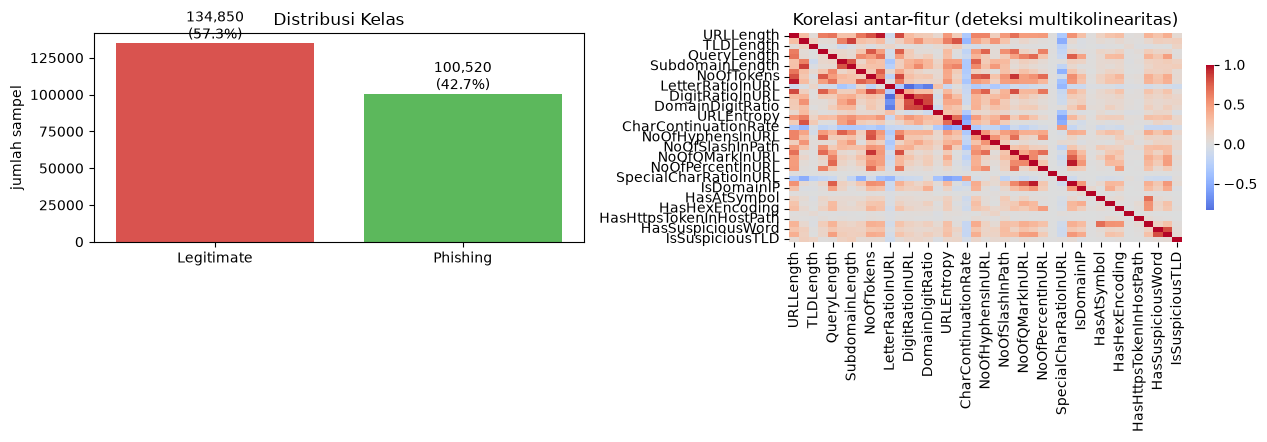


Statistik deskriptif fitur:
                             mean    std    min    50%      max
URLLength                   32.34  41.77  11.00  25.00  6097.00
DomainLength                18.45   9.84   4.00  16.00   110.00
TLDLength                    2.76   0.60   2.00   3.00    13.00
PathLength                   3.72  23.50   0.00   0.00  4248.00
QueryLength                  2.22  24.90   0.00   0.00  3391.00
NoOfSubDomain                0.41   0.68   0.00   0.00    10.00
SubdomainLength              4.93   9.85   0.00   0.00    95.00
LongestTokenLength          12.58  16.07   4.00  10.00  3108.00
NoOfTokens                   4.32   4.76   3.00   3.00   755.00
NoOfLettersInURL            24.94  29.08   4.00  20.00  5196.00
LetterRatioInURL             0.78   0.08   0.12   0.80     0.94
NoOfDigitsInURL              1.88  11.90   0.00   0.00  2011.00
DigitRatioInURL              0.03   0.07   0.00   0.00     0.68
NoOfDigitsInDomain           0.88   2.78   0.00   0.00    67.00
DomainDigit

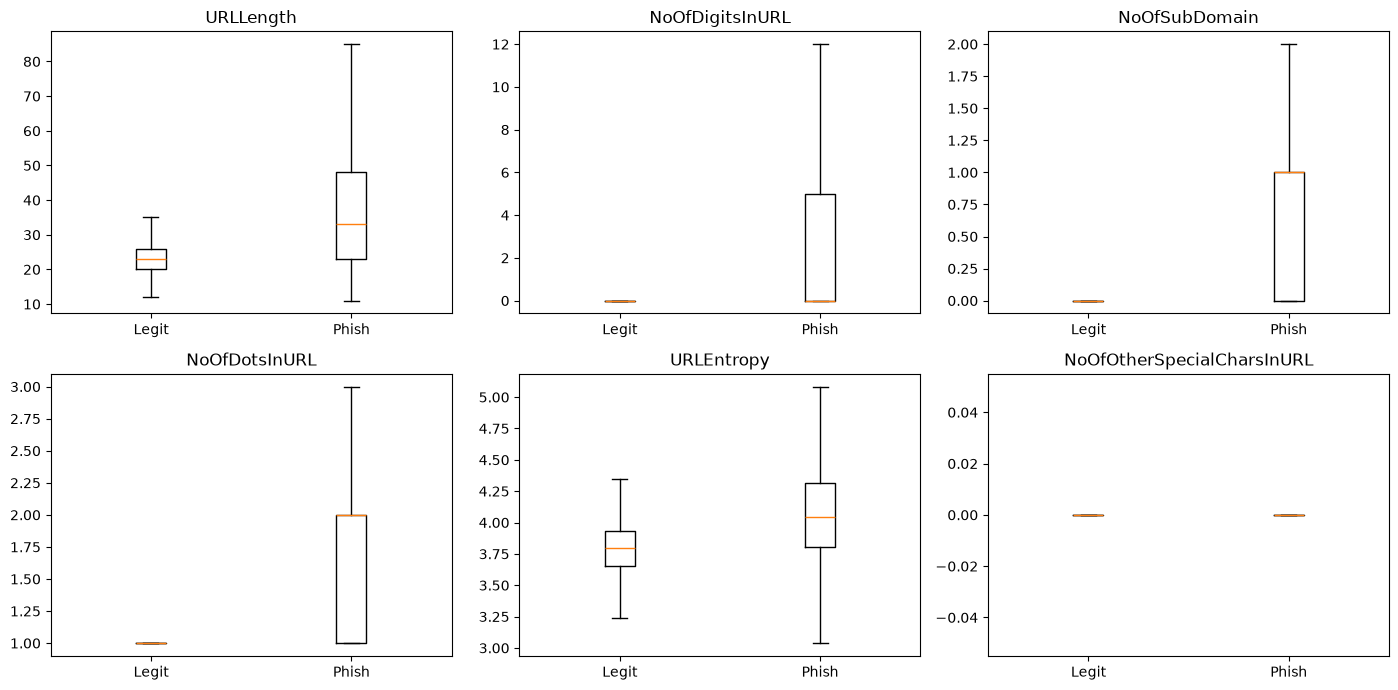


Rata-rata fitur kunci per kelas:
kelas                       Legitimate  Phishing
URLLength                        23.23     44.56
NoOfDigitsInURL                   0.05      4.34
NoOfSubDomain                     0.16      0.75
NoOfDotsInURL                     1.16      1.97
URLEntropy                        3.79      4.08
NoOfOtherSpecialCharsInURL        0.00      0.00

Pasangan fitur |korelasi|>0.85 (kandidat redundan):
[('URLLength', 'NoOfLettersInURL', np.float64(0.96)), ('DomainLength', 'SubdomainLength', np.float64(0.86)), ('NoOfTokens', 'NoOfEqualsInURL', np.float64(0.89)), ('NoOfAmpersandInURL', 'NoOfParams', np.float64(0.95))]


In [ ]:
# 2b. EDA (Exploratory Data Analysis)  -- bahan untuk bab analisis
eda = X.copy()
eda['kelas'] = np.where(y == 0, 'Phishing', 'Legitimate')

print("Ringkasan dataset (setelah fitur dibangun):")
print(f"  Total baris  : {len(eda):,}")
print(f"  Total fitur  : {X.shape[1]}")
print(f"  Missing value: {int(X.isnull().sum().sum())}  (0 = bersih)")
print(f"  Baris duplikat fitur: {X.duplicated().sum():,}")

# 1) Distribusi kelas + korelasi antar-fitur
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
counts = eda['kelas'].value_counts()
bars = ax[0].bar(counts.index, counts.values, color=['#d9534f', '#5cb85c'])
for b, v in zip(bars, counts.values):
    ax[0].text(b.get_x() + b.get_width()/2, v, f"{v:,}\n({v/len(eda)*100:.1f}%)",
               ha='center', va='bottom')
ax[0].set_title("Distribusi Kelas")
ax[0].set_ylabel("jumlah sampel")

sns.heatmap(X.corr(), cmap='coolwarm', center=0, ax=ax[1], cbar_kws={'shrink': .7})
ax[1].set_title("Korelasi antar-fitur (deteksi multikolinearitas)")
plt.tight_layout()
plt.show()

# 2) Statistik deskriptif
print("\nStatistik deskriptif fitur:")
print(X.describe().T[['mean', 'std', 'min', '50%', 'max']].round(2).to_string())

# 3) Sebaran fitur kunci per kelas (boxplot, outlier disembunyikan agar terbaca)
key_feats = [f for f in ['URLLength', 'NoOfDigitsInURL', 'NoOfSubDomain',
                         'NoOfDotsInURL', 'URLEntropy', 'NoOfOtherSpecialCharsInURL']
             if f in X.columns]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for axx, f in zip(axes.ravel(), key_feats):
    data_l = eda.loc[eda['kelas'] == 'Legitimate', f]
    data_p = eda.loc[eda['kelas'] == 'Phishing', f]
    axx.boxplot([data_l, data_p], showfliers=False)
    axx.set_xticks([1, 2]); axx.set_xticklabels(['Legit', 'Phish'])
    axx.set_title(f)
plt.tight_layout()
plt.show()

# 4) Rata-rata fitur kunci per kelas (perbandingan numerik)
print("\nRata-rata fitur kunci per kelas:")
print(eda.groupby('kelas')[key_feats].mean().round(2).T.to_string())

# 5) Pasangan fitur berkorelasi tinggi (>0.85) -> kandidat redundan untuk RFECV
cm = X.corr().abs()
high = [(cm.columns[i], cm.columns[j], round(cm.iloc[i, j], 2))
        for i in range(len(cm)) for j in range(i+1, len(cm)) if cm.iloc[i, j] > 0.85]
print("\nPasangan fitur |korelasi|>0.85 (kandidat redundan):")
print(high if high else "  (tidak ada -> antar-fitur relatif independen)")

In [ ]:
# 3. SPLIT PER-DOMAIN (GroupShuffleSplit)
#    Mencegah domain yang sama muncul di train DAN test. Tanpa ini, model bisa
#    "menghafal" domain dan nilai test jadi optimis palsu.
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)
y_train, y_test = y[train_idx], y[test_idx]
g_train, g_test = groups[train_idx], groups[test_idx]

# --- Validasi leakage ---
overlap_dom = len(set(g_train) & set(g_test))
overlap_url = len(set(df['URL'].iloc[train_idx]) & set(df['URL'].iloc[test_idx]))
assert overlap_dom == 0, "Domain bocor antara train & test!"
assert overlap_url == 0, "URL bocor antara train & test!"

print(f"Train : {len(X_train):,} baris  ({(y_train==0).mean()*100:.1f}% phishing)")
print(f"Test  : {len(X_test):,} baris  ({(y_test==0).mean()*100:.1f}% phishing)")
print(f"Domain unik train={len(set(g_train)):,} | test={len(set(g_test)):,}")
print(f"Leakage check -> overlap domain={overlap_dom}, overlap URL={overlap_url}  (harus 0)")

# Catatan: baris fitur identik antar train/test BUKAN leakage di sini.
# Dua URL berbeda dengan struktur mirip wajar menghasilkan vektor fitur sama;
# yang penting domain & URL-nya tidak bocor (sudah dijamin di atas).

Train : 182,147 baris  (40.7% phishing)
Test  : 53,223 baris  (49.7% phishing)
Domain unik train=136,846 | test=34,212
Leakage check -> overlap domain=0, overlap URL=0  (harus 0)


In [ ]:
# 4. CEK KESEIMBANGAN KELAS (pakai data TRAIN saja, jangan intip test)
vc = pd.Series(y_train).value_counts(normalize=True).rename({0: 'Phishing(0)', 1: 'Legitimate(1)'})
print("Distribusi label (train):")
print(vc.round(4))

imb = vc.max() / vc.min()
print(f"\nRasio imbalance: {imb:.2f}x ->",
      "gunakan F1/Recall sebagai metrik utama" if imb > 1.5 else "relatif seimbang")

# scale_pos_weight untuk XGBoost (kelas positif default = label 1 / legitimate).
neg = int((y_train == 0).sum())   # phishing
pos = int((y_train == 1).sum())   # legitimate
scale_pos_weight = neg / pos
print(f"scale_pos_weight (neg/pos) = {scale_pos_weight:.3f}")

Distribusi label (train):
Legitimate(1)    0.5934
Phishing(0)      0.4066
Name: proportion, dtype: float64

Rasio imbalance: 1.46x -> relatif seimbang
scale_pos_weight (neg/pos) = 0.685


RFECV memakai subsample 50,000 baris training (untuk kecepatan).
RFECV selesai 37.7s | jumlah fitur optimal = 19

Fitur TERPILIH (19): ['URLLength', 'DomainLength', 'TLDLength', 'PathLength', 'NoOfSubDomain', 'SubdomainLength', 'LongestTokenLength', 'NoOfTokens', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDigitsInURL', 'DigitRatioInURL', 'DomainEntropy', 'CharContinuationRate', 'NoOfDotsInURL', 'NoOfSlashInPath', 'SpecialCharRatioInURL', 'HasSuspiciousWord', 'IsSuspiciousTLD']
Fitur DIBUANG  (22): ['QueryLength', 'NoOfDigitsInDomain', 'DomainDigitRatio', 'VowelRatioInURL', 'URLEntropy', 'NoOfHyphensInURL', 'NoOfHyphensInDomain', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfPercentInURL', 'NoOfOtherSpecialCharsInURL', 'NoOfParams', 'IsDomainIP', 'IsPortInURL', 'HasAtSymbol', 'HasDoubleSlashInPath', 'HasHexEncoding', 'IsPunycode', 'HasHttpsTokenInHostPath', 'HasObfuscation', 'SuspiciousWordCount']

Ranking RFE (1 = terpilih, makin besar makin awal dibuang):
         

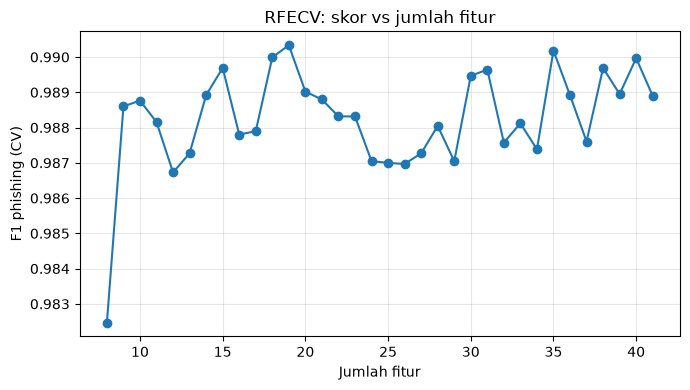


Dimensi setelah seleksi -> X_train (182147, 19), X_test (53223, 19)


In [ ]:
# 4b. SELEKSI FITUR DENGAN RFECV  (fit HANYA pada data TRAINING -> tidak ada leakage)
#     RFECV memilih subset fitur terbaik secara cross-validated. Skoring = F1 phishing
#     supaya seleksi fokus mendeteksi kelas phishing. RFE TIDAK pernah melihat data test.
from sklearn.feature_selection import RFECV

# Subsample train agar pencarian cepat (RFECV me-refit model berkali-kali).
rng = np.random.RandomState(RANDOM_STATE)
sel_idx = rng.choice(len(X_train), size=min(50000, len(X_train)), replace=False)
X_sel, y_sel = X_train.iloc[sel_idx], y_train[sel_idx]
print(f"RFECV memakai subsample {len(X_sel):,} baris training (untuk kecepatan).")

rfe_estimator = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, tree_method='hist',
    eval_metric='logloss', importance_type='gain',
    random_state=RANDOM_STATE, n_jobs=-1,
)

rfecv = RFECV(
    estimator=rfe_estimator,
    step=1,
    min_features_to_select=8,
    cv=3,
    scoring=f1_phish,
    n_jobs=-1,
)
t0 = time.time()
rfecv.fit(X_sel, y_sel)
print(f"RFECV selesai {time.time()-t0:.1f}s | jumlah fitur optimal = {rfecv.n_features_}")

# Urutkan fitur terpilih sesuai FEATURE_ORDER (penting untuk konsistensi dgn backend).
SELECTED_FEATURES = [f for f, keep in zip(FEATURE_ORDER, rfecv.support_) if keep]
dropped = [f for f, keep in zip(FEATURE_ORDER, rfecv.support_) if not keep]
print(f"\nFitur TERPILIH ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}")
print(f"Fitur DIBUANG  ({len(dropped)}): {dropped}")

rank_df = pd.DataFrame({'fitur': FEATURE_ORDER, 'rank': rfecv.ranking_}).sort_values('rank')
print("\nRanking RFE (1 = terpilih, makin besar makin awal dibuang):")
print(rank_df.to_string(index=False))

# Plot skor CV vs jumlah fitur (bahan analisis: berapa fitur cukup). Robust antar versi sklearn.
try:
    scores = rfecv.cv_results_['mean_test_score']   # sklearn >= 1.0
except (AttributeError, KeyError):
    scores = getattr(rfecv, 'grid_scores_', None)   # sklearn lama
if scores is not None:
    plt.figure(figsize=(7, 4))
    plt.plot(range(rfecv.min_features_to_select, rfecv.min_features_to_select + len(scores)),
             scores, marker='o')
    plt.xlabel("Jumlah fitur"); plt.ylabel("F1 phishing (CV)")
    plt.title("RFECV: skor vs jumlah fitur"); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

# Terapkan seleksi ke train & test. SEMUA sel berikutnya memakai subset ini.
X_train = X_train[SELECTED_FEATURES]
X_test  = X_test[SELECTED_FEATURES]
print(f"\nDimensi setelah seleksi -> X_train {X_train.shape}, X_test {X_test.shape}")

In [ ]:
# 4c. HYPERPARAMETER TUNING (DOMAIN-AWARE, anti-leakage)
#     Pakai GroupKFold agar fold CV tidak memecah domain yang sama -> tuning jujur.
#     Skoring = F1 phishing. Subsample untuk kecepatan.
tun_idx = rng.choice(len(X_train), size=min(60000, len(X_train)), replace=False)
X_tun, y_tun, g_tun = X_train.iloc[tun_idx], y_train[tun_idx], g_train[tun_idx]
print(f"Tuning memakai {len(X_tun):,} baris training (GroupKFold 3-fold, domain-aware).")

param_dist = {
    'n_estimators': [300, 400, 500, 600],
    'learning_rate': [0.03, 0.05, 0.08, 0.1],
    'max_depth': [4, 5, 6, 7, 8],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [1.0, 2.0, 3.0],
}

base_est = xgb.XGBClassifier(
    eval_metric='logloss', tree_method='hist', importance_type='gain',
    scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, n_jobs=1,
)

gkf = GroupKFold(n_splits=3)
cv_splits = list(gkf.split(X_tun, y_tun, groups=g_tun))

search = RandomizedSearchCV(
    estimator=base_est,
    param_distributions=param_dist,
    n_iter=20,
    scoring=f1_phish,
    cv=cv_splits,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)
t0 = time.time()
search.fit(X_tun, y_tun)
best_params = search.best_params_
print(f"\nTuning selesai {time.time()-t0:.1f}s")
print(f"F1 phishing CV terbaik = {search.best_score_:.4f}")
print(f"Best params: {best_params}")

Tuning memakai 60,000 baris training (GroupKFold 3-fold, domain-aware).
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Tuning selesai 24.1s
F1 phishing CV terbaik = 0.9921
Best params: {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0.5, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.9}


In [ ]:
# 5. TRAINING MODEL FINAL  (best_params hasil tuning + early stopping)
#    Memakai SELECTED_FEATURES (sel 4b) & best_params (sel 4c).

# Validasi untuk early stopping dipisah dari TRAIN, juga per-domain (anti bocor).
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
tr_idx, val_idx = next(gss_val.split(X_train, y_train, groups=g_train))
X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
y_tr, y_val = y_train[tr_idx], y_train[val_idx]
print(f"Sub-train={len(X_tr):,} | Validasi(early stop)={len(X_val):,} | fitur={X_train.shape[1]}")

# Default aman; ditimpa best_params kalau sel tuning (4c) sudah dijalankan.
final_params = dict(
    n_estimators=600, learning_rate=0.05, max_depth=6, min_child_weight=5,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=2.0, gamma=0.1,
)
try:
    final_params.update(best_params)
    print("Memakai best_params hasil tuning.")
except NameError:
    print("best_params tidak ada -> memakai parameter default.")

# Beri ruang lebih banyak pohon; early stopping yang menentukan titik henti optimal.
final_params['n_estimators'] = max(final_params.get('n_estimators', 600), 1000)

model = xgb.XGBClassifier(
    **final_params,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    early_stopping_rounds=50,
    tree_method='hist',
    importance_type='gain',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

t0 = time.time()
model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
best_it = getattr(model, 'best_iteration', None)
print(f"Training selesai {time.time()-t0:.1f}s | best_iteration = {best_it}")

acc_tr = accuracy_score(y_tr, model.predict(X_tr))
acc_te = accuracy_score(y_test, model.predict(X_test))
gap = abs(acc_tr - acc_te)
print(f"Akurasi sub-train: {acc_tr*100:.2f}% | Akurasi TEST: {acc_te*100:.2f}%")
print("Overfitting gap:", f"{gap*100:.2f}%", "(OK)" if gap < 0.05 else "(perhatikan)")

print("\nCATATAN PENTING UNTUK SIDANG:")
print("Akurasi turun dari 99.9% itu WAJAR & SEHAT. Angka realistis (mis. ~88-95%)")
print("mencerminkan performa nyata pada domain baru, bukan hafalan artefak crawling.")

Sub-train=147,536 | Validasi(early stop)=34,611 | fitur=19
Memakai best_params hasil tuning.
Training selesai 2.8s | best_iteration = 425
Akurasi sub-train: 99.70% | Akurasi TEST: 99.58%
Overfitting gap: 0.12% (OK)

CATATAN PENTING UNTUK SIDANG:
Akurasi turun dari 99.9% itu WAJAR & SEHAT. Angka realistis (mis. ~88-95%)
mencerminkan performa nyata pada domain baru, bukan hafalan artefak crawling.


In [ ]:
# 5b. OPTIMASI THRESHOLD KEPUTUSAN
#     Default 0.5 belum tentu optimal. Kita cari threshold P(phishing) yang
#     memaksimalkan F1 phishing PADA SET VALIDASI (bukan test -> test tetap jujur).
val_proba_phish = model.predict_proba(X_val)[:, 0]   # P(phishing) di validasi
val_is_phish = (y_val == 0).astype(int)

prec_v, rec_v, thr_v = precision_recall_curve(val_is_phish, val_proba_phish)
f1_v = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-9)
best_i = int(np.argmax(f1_v[:-1]))         # thr_v lebih pendek 1 elemen
BEST_THRESHOLD = float(thr_v[best_i])
print(f"Threshold optimal (maks F1 phishing di validasi) = {BEST_THRESHOLD:.3f}")
print(f"  Pada validasi -> Precision={prec_v[best_i]:.4f}  Recall={rec_v[best_i]:.4f}  F1={f1_v[best_i]:.4f}")
print(f"  (Bandingkan dengan default 0.5)")

def predict_with_threshold(proba_phish, thr=BEST_THRESHOLD):
    """Kembalikan label: 0=phishing jika P(phishing)>=thr, selain itu 1=legitimate."""
    return np.where(proba_phish >= thr, 0, 1)

Threshold optimal (maks F1 phishing di validasi) = 0.354
  Pada validasi -> Precision=0.9963  Recall=0.9900  F1=0.9932
  (Bandingkan dengan default 0.5)


Threshold dipakai = 0.354

Classification report (0 = Phishing, 1 = Legitimate):
               precision    recall  f1-score   support

  Phishing(0)       1.00      0.99      1.00     26452
Legitimate(1)       0.99      1.00      1.00     26771

     accuracy                           1.00     53223
    macro avg       1.00      1.00      1.00     53223
 weighted avg       1.00      1.00      1.00     53223



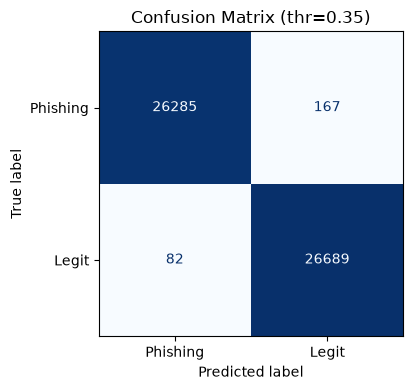

[Deteksi Phishing] Precision=0.9969  Recall=0.9937  F1=0.9953
Accuracy keseluruhan = 0.9953

(Pembanding thr=0.5) Recall phishing=0.9932, F1 phishing=0.9957


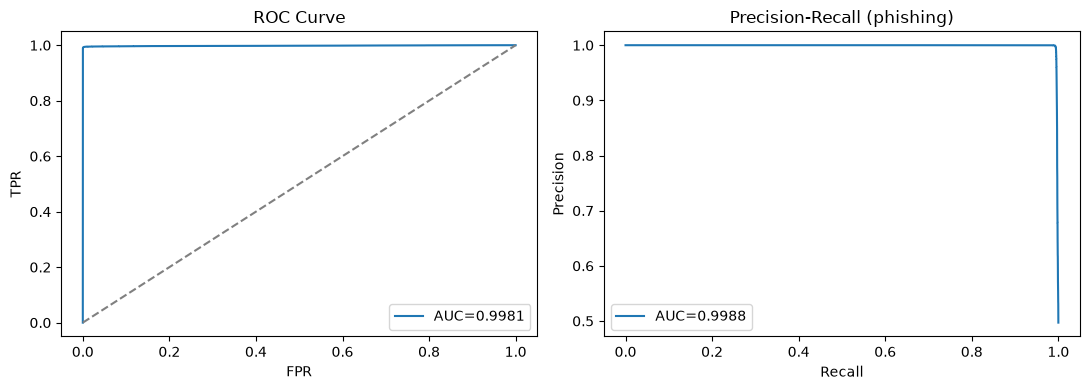

In [ ]:
# 6. EVALUASI DI TEST SET  (memakai threshold optimal dari sel 5b)
y_proba_phish = model.predict_proba(X_test)[:, 0]      # P(phishing) = kelas 0
y_pred = predict_with_threshold(y_proba_phish)         # 0=phishing, 1=legit

print(f"Threshold dipakai = {BEST_THRESHOLD:.3f}")
print("\nClassification report (0 = Phishing, 1 = Legitimate):")
print(classification_report(y_test, y_pred, target_names=['Phishing(0)', 'Legitimate(1)']))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Phishing', 'Legit']).plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f"Confusion Matrix (thr={BEST_THRESHOLD:.2f})")
plt.tight_layout()
plt.show()

# Metrik dengan FOKUS deteksi phishing (kelas positif = phishing = label 0).
prec = precision_score(y_test, y_pred, pos_label=0)
rec  = recall_score(y_test, y_pred, pos_label=0)
f1   = f1_score(y_test, y_pred, pos_label=0)
print(f"[Deteksi Phishing] Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")
print(f"Accuracy keseluruhan = {accuracy_score(y_test, y_pred):.4f}")

# Bandingkan dgn threshold default 0.5 (untuk pembahasan)
y_pred_05 = predict_with_threshold(y_proba_phish, 0.5)
print(f"\n(Pembanding thr=0.5) Recall phishing={recall_score(y_test, y_pred_05, pos_label=0):.4f}, "
      f"F1 phishing={f1_score(y_test, y_pred_05, pos_label=0):.4f}")

# ROC & PR memakai skor P(phishing) terhadap target biner phishing (independen threshold).
y_is_phish = (y_test == 0).astype(int)
fpr, tpr, _ = roc_curve(y_is_phish, y_proba_phish)
pr_c, rc_c, _ = precision_recall_curve(y_is_phish, y_proba_phish)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(fpr, tpr, label=f"AUC={auc(fpr, tpr):.4f}")
ax[0].plot([0, 1], [0, 1], '--', color='gray')
ax[0].set_title("ROC Curve"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
ax[1].plot(rc_c, pr_c, label=f"AUC={auc(rc_c, pr_c):.4f}")
ax[1].set_title("Precision-Recall (phishing)"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()
plt.tight_layout()
plt.show()

F1 phishing asli = 0.9882 | F1 label-acak (rata2) = 0.1580 | p-value = 0.0323
=> Model SIGNIFIKAN (bukan kebetulan)

Top 10 fitur (gain):
PathLength            0.5896
NoOfSlashInPath       0.2632
IsSuspiciousTLD       0.0554
NoOfDigitsInURL       0.0205
URLLength             0.0196
DomainLength          0.0125
NoOfSubDomain         0.0072
TLDLength             0.0068
LongestTokenLength    0.0041
DigitRatioInURL       0.0038
dtype: float32


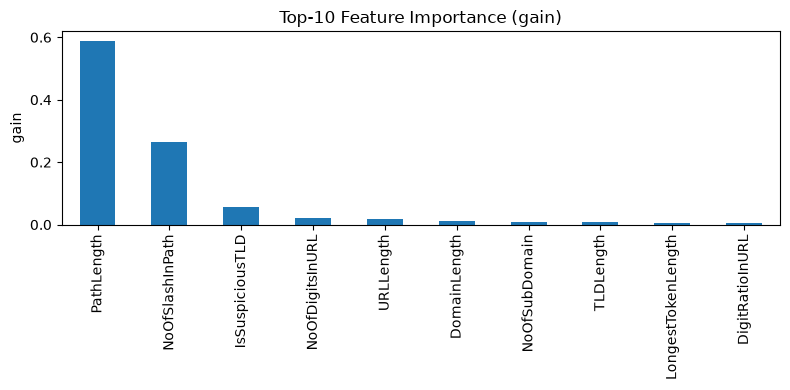


Dominasi fitur teratas 'PathLength' = 59.0% dari total gain -> sehat, tidak ada satu fitur yg mendominasi ekstrem


In [ ]:
# 7. PERMUTATION TEST + FEATURE IMPORTANCE
# (a) Permutation test: memastikan performa BUKAN kebetulan. Pakai subset + CV kecil
#     supaya cepat. Estimator dibuat tanpa early_stopping agar kompatibel dgn CV.
sub = np.random.RandomState(RANDOM_STATE).choice(
    len(X_train), size=min(20000, len(X_train)), replace=False)
n_trees = (best_it + 1) if best_it else 300
perm_model = xgb.XGBClassifier(
    n_estimators=n_trees, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0,
    tree_method='hist', eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1,
)
score, perm_scores, pvalue = permutation_test_score(
    perm_model, X_train.iloc[sub], y_train[sub],
    scoring=f1_phish, cv=3, n_permutations=30, n_jobs=-1, random_state=RANDOM_STATE,
)
print(f"F1 phishing asli = {score:.4f} | F1 label-acak (rata2) = {perm_scores.mean():.4f} | p-value = {pvalue:.4f}")
print("=> Model SIGNIFIKAN (bukan kebetulan)" if pvalue < 0.05 else "=> Model TIDAK signifikan")

# (b) Feature importance (gain) dari model utama -> hanya fitur terpilih (SELECTED_FEATURES).
imp = pd.Series(model.feature_importances_, index=list(X_train.columns)).sort_values(ascending=False)
print("\nTop 10 fitur (gain):")
print(imp.head(10).round(4))

plt.figure(figsize=(8, 4))
imp.head(10).plot(kind='bar')
plt.title("Top-10 Feature Importance (gain)")
plt.ylabel("gain")
plt.tight_layout()
plt.show()

top_share = imp.iloc[0] / imp.sum() * 100
print(f"\nDominasi fitur teratas '{imp.index[0]}' = {top_share:.1f}% dari total gain ->",
      "WASPADA, cek apakah ini leakage" if top_share > 60 else "sehat, tidak ada satu fitur yg mendominasi ekstrem")

CATATAN interpretasi:
  Nilai SHAP menjelaskan skor kelas POSITIF model = Legitimate (label 1).
  SHAP > 0  -> mendorong prediksi ke 'legitimate'
  SHAP < 0  -> mendorong prediksi ke 'phishing'



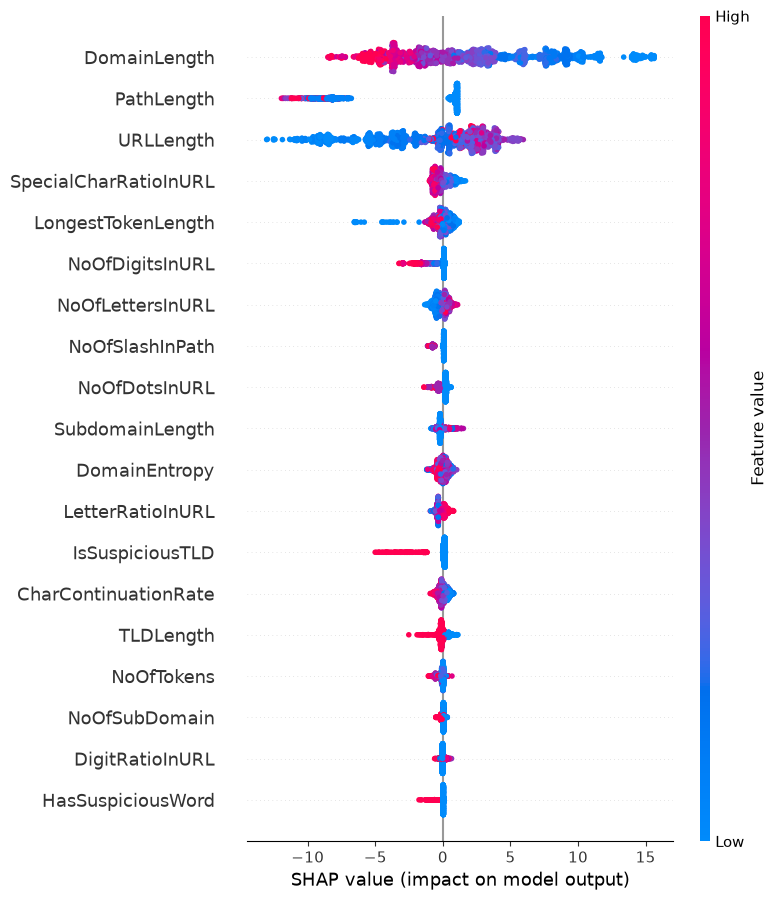

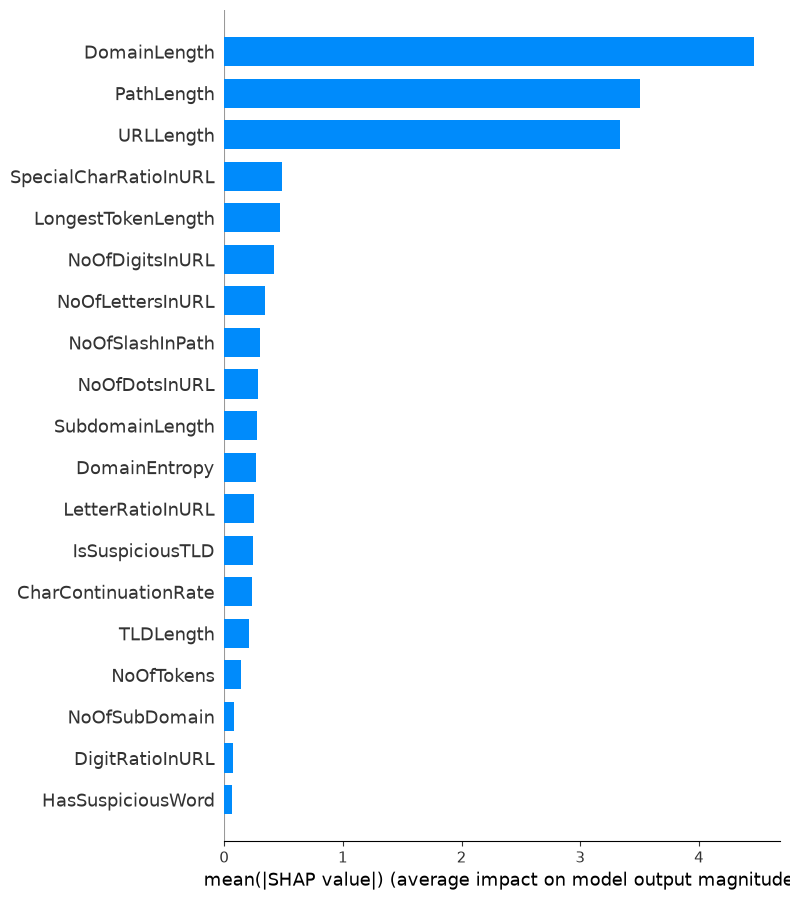

Contoh lokal (paling yakin phishing): P(phishing)=1.000


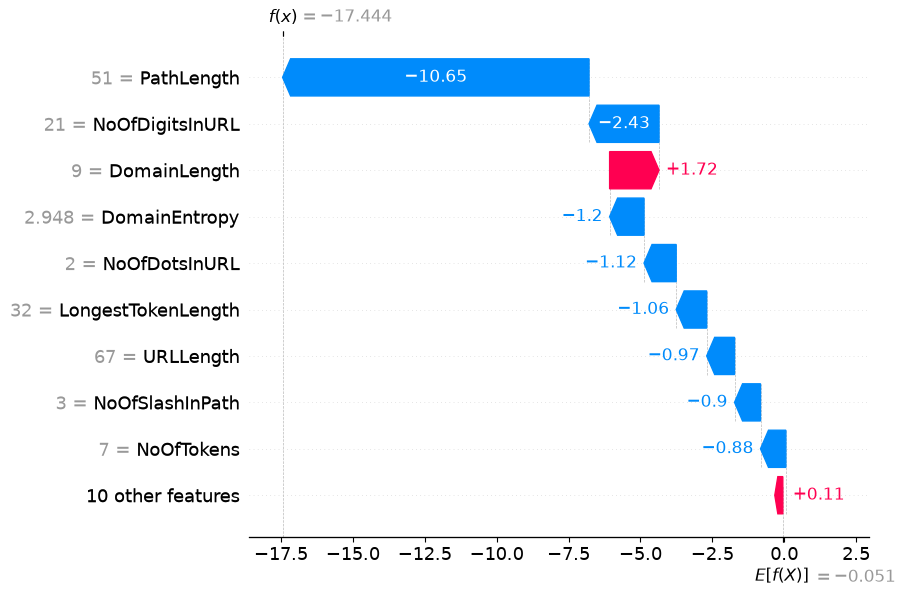

In [ ]:
# 7b. SHAP — EXPLAINABILITY (menjelaskan KENAPA model memutuskan)
#     Jika belum terpasang:  pip install shap
try:
    import shap
except ImportError:
    print("shap belum terpasang. Jalankan di terminal:  pip install shap")
    shap = None

if shap is not None:
    # Sampel test untuk kecepatan (TreeExplainer cepat, tapi plot besar tetap berat).
    samp = X_test.sample(min(2000, len(X_test)), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(samp)

    print("CATATAN interpretasi:")
    print("  Nilai SHAP menjelaskan skor kelas POSITIF model = Legitimate (label 1).")
    print("  SHAP > 0  -> mendorong prediksi ke 'legitimate'")
    print("  SHAP < 0  -> mendorong prediksi ke 'phishing'\n")

    # (1) Beeswarm: distribusi pengaruh tiap fitur
    shap.summary_plot(shap_values, samp, show=True)

    # (2) Bar: rata-rata |SHAP| = kepentingan global (lebih jujur drpd 'gain')
    shap.summary_plot(shap_values, samp, plot_type='bar', show=True)

    # (3) Penjelasan LOKAL untuk 1 URL yang paling diyakini phishing
    proba_samp = model.predict_proba(samp)[:, 0]
    idx_phish = int(np.argmax(proba_samp))
    print(f"Contoh lokal (paling yakin phishing): P(phishing)={proba_samp[idx_phish]:.3f}")
    try:
        expl = explainer(samp)
        shap.plots.waterfall(expl[idx_phish], show=True)
    except Exception as e:
        print(f"(waterfall dilewati karena versi shap: {e})")
else:
    print("Lewati SHAP (modul tidak tersedia).")

In [ ]:
# 8. SANITY CHECK PADA URL NYATA  <-- bukti leakage & skew hilang
#    extract_url_features() menghasilkan SEMUA fitur; ambil subset SELECTED_FEATURES
#    (urutan sama dgn training) lalu pakai BEST_THRESHOLD. google.com harus 'legitimate'.
test_urls = [
    ("https://www.google.com",                         "legitimate"),
    ("https://github.com",                             "legitimate"),
    ("https://www.paypal.com",                         "legitimate"),
    ("https://en.wikipedia.org/wiki/Phishing",         "legitimate"),
    ("https://www.bankmandiri.co.id",                  "legitimate"),
    ("http://paypal.com.verify-account.secure-login.tk/webscr?cmd=update", "phishing"),
    ("http://192.168.10.5:8080/login/confirm-account/update.php",          "phishing"),
    ("http://secure-update-account-verify.000webhostapp.com/login",        "phishing"),
    ("http://bit.ly-account-verify.com/login@signin",                      "phishing"),
]

rows = []
for u, expected in test_urls:
    feat = pd.DataFrame([extract_url_features(u)])[SELECTED_FEATURES]
    p_phish = float(model.predict_proba(feat)[0][0])   # kelas 0 = phishing
    pred = "phishing" if p_phish >= BEST_THRESHOLD else "legitimate"
    rows.append({
        "url": (u[:50] + '...') if len(u) > 50 else u,
        "harapan": expected,
        "prediksi": pred,
        "P(phishing)": round(p_phish, 3),
        "match": "OK" if pred == expected else "XX",
    })

res = pd.DataFrame(rows)
print(f"Threshold = {BEST_THRESHOLD:.3f}\n")
print(res.to_string(index=False))
n_ok = (res['match'] == 'OK').sum()
print(f"\nBenar {n_ok}/{len(res)} contoh.")
print("Jika 'google.com' sudah 'legitimate', berarti train-serving skew & leakage TERATASI.")

Threshold = 0.354

                                                  url    harapan   prediksi  P(phishing) match
                               https://www.google.com legitimate legitimate        0.009    OK
                                   https://github.com legitimate legitimate        0.001    OK
                               https://www.paypal.com legitimate legitimate        0.007    OK
               https://en.wikipedia.org/wiki/Phishing legitimate   phishing        1.000    XX
                        https://www.bankmandiri.co.id legitimate legitimate        0.042    OK
http://paypal.com.verify-account.secure-login.tk/w...   phishing   phishing        1.000    OK
http://192.168.10.5:8080/login/confirm-account/upd...   phishing   phishing        1.000    OK
http://secure-update-account-verify.000webhostapp....   phishing   phishing        1.000    OK
        http://bit.ly-account-verify.com/login@signin   phishing   phishing        1.000    OK

Benar 8/9 contoh.
Jika 'google

In [ ]:
# 9. EXPORT MODEL + SCHEMA + THRESHOLD  (dipakai backend app.py)
import joblib

joblib.dump(model, 'model_xgboost_url.pkl')
joblib.dump(SELECTED_FEATURES, 'url_feature_schema.pkl')
joblib.dump(BEST_THRESHOLD, 'decision_threshold.pkl')
print(f"Tersimpan:")
print(f"  - model_xgboost_url.pkl")
print(f"  - url_feature_schema.pkl ({len(SELECTED_FEATURES)} fitur): {SELECTED_FEATURES}")
print(f"  - decision_threshold.pkl = {BEST_THRESHOLD:.3f}")

# Smoke test: load balik + prediksi google.com pakai extractor + threshold yang sama.
m = joblib.load('model_xgboost_url.pkl')
sch = joblib.load('url_feature_schema.pkl')
thr = joblib.load('decision_threshold.pkl')
feat = pd.DataFrame([extract_url_features('https://www.google.com')])[sch]
p = float(m.predict_proba(feat)[0][0])
print(f"\nReload OK. google.com -> P(phishing)={p:.4f}, thr={thr:.3f} ->",
      "phishing" if p >= thr else "legitimate")

print("\nPENTING untuk backend:")
print(" - app.py memakai url_features.extract_url_features (semua fitur) lalu menyaring")
print("   ke kolom url_feature_schema.pkl, dan ambang keputusan dari decision_threshold.pkl.")
print(" - JANGAN pakai lagi model_xgboost_full.pkl / fallback (berbasis fitur konten = leakage).")

Tersimpan:
  - model_xgboost_url.pkl
  - url_feature_schema.pkl (19 fitur): ['URLLength', 'DomainLength', 'TLDLength', 'PathLength', 'NoOfSubDomain', 'SubdomainLength', 'LongestTokenLength', 'NoOfTokens', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDigitsInURL', 'DigitRatioInURL', 'DomainEntropy', 'CharContinuationRate', 'NoOfDotsInURL', 'NoOfSlashInPath', 'SpecialCharRatioInURL', 'HasSuspiciousWord', 'IsSuspiciousTLD']
  - decision_threshold.pkl = 0.354

Reload OK. google.com -> P(phishing)=0.0093, thr=0.354 -> legitimate

PENTING untuk backend:
 - app.py memakai url_features.extract_url_features (semua fitur) lalu menyaring
   ke kolom url_feature_schema.pkl, dan ambang keputusan dari decision_threshold.pkl.
 - JANGAN pakai lagi model_xgboost_full.pkl / fallback (berbasis fitur konten = leakage).
